# Pascal-Part-116 Dataset Analysis

Exploratory analysis of images, parent-object masks, and part annotations for the text-conditioned object-relative geometry project.

## 1. Setup and Dataset Paths

Define the dataset and output locations and verify that Pascal-Part-116 is available.

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "PascalPart116"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "data_analysis"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset:", DATASET_DIR.resolve())
print("Dataset exists:", DATASET_DIR.exists())
print("Output folder:", OUTPUT_DIR.resolve())

## 2. Dataset Structure

Inspect the top-level folders in the downloaded dataset.

In [ ]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_DIR.resolve()}"
    )

for path in sorted(DATASET_DIR.iterdir()):
    item_type = "Folder" if path.is_dir() else "File"
    print(f"{item_type:6} | {path.name}")

## 3. Split and Annotation Integrity

Count valid files and confirm that every RGB image has matching object and part annotations. Hidden macOS resource-fork files are excluded.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

def files_by_stem(directory):
    return {
        path.stem: path
        for path in sorted(directory.iterdir())
        if path.is_file()
        and not path.name.startswith(".")
        and path.suffix.lower() in IMAGE_SUFFIXES
    }

split_files = {}
integrity_rows = []

for split in ("train", "val"):
    images = files_by_stem(DATASET_DIR / "images" / split)
    objects = files_by_stem(DATASET_DIR / "annotations_detectron2_obj" / split)
    parts = files_by_stem(DATASET_DIR / "annotations_detectron2_part" / split)
    matched = images.keys() & objects.keys() & parts.keys()
    split_files[split] = {"images": images, "objects": objects, "parts": parts}
    integrity_rows.append({
        "split": split,
        "images": len(images),
        "object masks": len(objects),
        "part masks": len(parts),
        "matched triplets": len(matched),
        "incomplete images": len(images.keys() - matched),
    })

integrity_df = pd.DataFrame(integrity_rows).set_index("split")
integrity_df

In [ ]:
assert (integrity_df["incomplete images"] == 0).all(), (
    "Some images do not have both annotation types."
)

ax = integrity_df[["images", "object masks", "part masks"]].plot(
    kind="bar", figsize=(8, 4), rot=0
)
ax.set(title="Pascal-Part-116 files by split", ylabel="File count")
plt.tight_layout()
plt.show()

## 4. Image Dimensions

Measure image dimensions and aspect ratios to guide resizing and batching decisions.

In [ ]:
dimension_rows = []

for split, groups in split_files.items():
    for stem, image_path in groups["images"].items():
        with Image.open(image_path) as image:
            width, height = image.size
        dimension_rows.append({
            "split": split,
            "stem": stem,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
        })

dimensions_df = pd.DataFrame(dimension_rows)
dimensions_df.groupby("split")[["width", "height", "aspect_ratio"]].describe().round(2)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=dimensions_df, x="aspect_ratio", hue="split", bins=40, ax=axes[0])
axes[0].set_title("Image aspect-ratio distribution")
sns.scatterplot(
    data=dimensions_df, x="width", y="height", hue="split", alpha=0.35, ax=axes[1]
)
axes[1].set_title("Image dimensions")
plt.tight_layout()
plt.show()

## 5. Annotation Label Summary

Inspect label IDs on a reproducible sample of masks. Pascal-Part-116 uses `255` as the ignored/background label.

In [ ]:
IGNORE_LABEL = 255
MASK_SAMPLE_SIZE = 500
rng = np.random.default_rng(42)
label_rows = []

for split, groups in split_files.items():
    stems = sorted(groups["images"].keys() & groups["objects"].keys() & groups["parts"].keys())
    if len(stems) > MASK_SAMPLE_SIZE:
        stems = sorted(rng.choice(stems, size=MASK_SAMPLE_SIZE, replace=False))
    for stem in stems:
        for annotation_type in ("objects", "parts"):
            labels = np.asarray(Image.open(groups[annotation_type][stem]))
            valid_labels = np.unique(labels[labels != IGNORE_LABEL])
            label_rows.append({
                "split": split,
                "stem": stem,
                "annotation_type": annotation_type,
                "label_count": len(valid_labels),
                "foreground_fraction": float(np.mean(labels != IGNORE_LABEL)),
            })

labels_df = pd.DataFrame(label_rows)
labels_df.groupby(["split", "annotation_type"])[
    ["label_count", "foreground_fraction"]
].describe().round(3)

## 6. Random Image–Object–Part Explorer

Run the next cell repeatedly to select a new valid image, parent object, and part. The table reports the numeric labels and readable names used by the masks.

,split,image_id,image_file,image_shape,object_id,object_name,part_id,part_name,object_pixels,part_pixels
0,train,2008_005380,2008_005380.jpg,"(500, 333, 3)",7,cat,49,paw,48791,2386


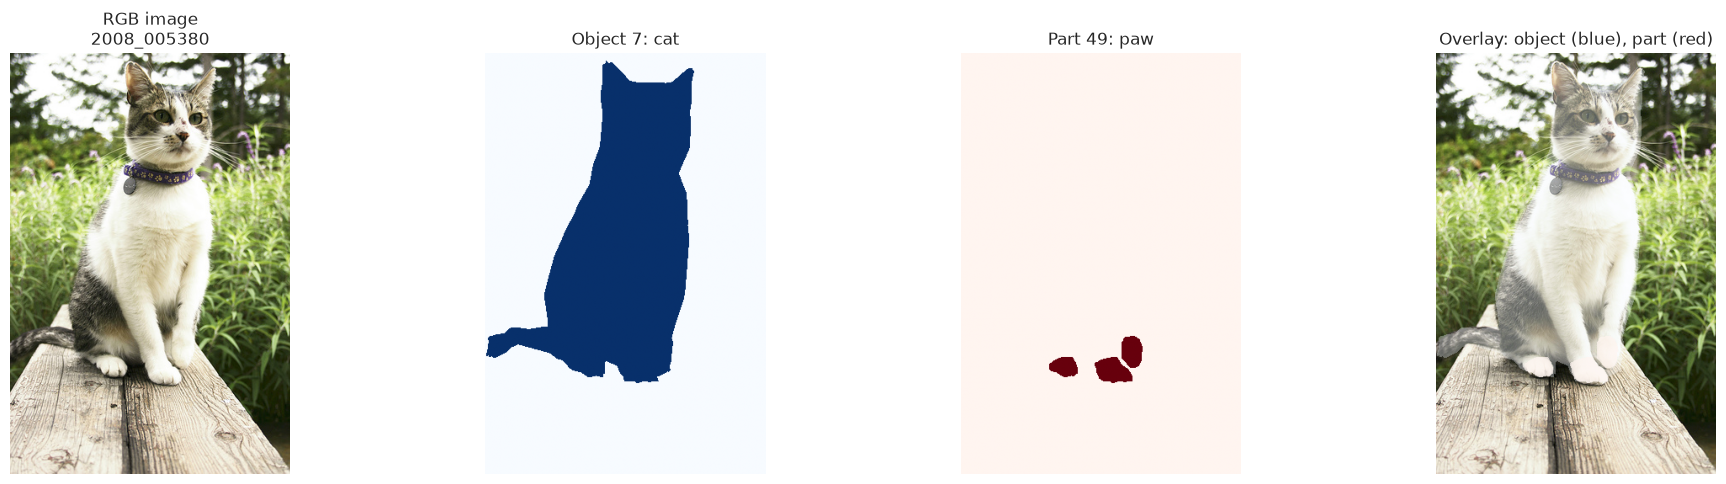

In [15]:
from IPython.display import display

# Object IDs follow the Pascal VOC order. Part IDs are assigned in the
# order below, matching the 116-class Pascal-Part label map.
PARTS_BY_OBJECT = {
    0: ("aeroplane", ("body", "stern", "wing", "tail", "engine", "wheel")),
    1: ("bicycle", ("wheel", "saddle", "handlebar", "chainwheel", "headlight")),
    2: ("bird", ("wing", "tail", "head", "eye", "beak", "torso", "neck", "leg", "foot")),
    4: ("bottle", ("body", "cap")),
    5: ("bus", ("wheel", "headlight", "front", "side", "back", "roof", "mirror", "license plate", "door", "window")),
    6: ("car", ("wheel", "headlight", "front", "side", "back", "roof", "mirror", "license plate", "door", "window")),
    7: ("cat", ("tail", "head", "eye", "torso", "neck", "leg", "nose", "paw", "ear")),
    9: ("cow", ("tail", "head", "eye", "torso", "neck", "leg", "ear", "muzzle", "horn")),
    11: ("dog", ("tail", "head", "eye", "torso", "neck", "leg", "nose", "paw", "ear", "muzzle")),
    12: ("horse", ("tail", "head", "eye", "torso", "neck", "leg", "ear", "muzzle", "hoof")),
    13: ("motorbike", ("wheel", "saddle", "handlebar", "headlight")),
    14: ("person", ("head", "eye", "torso", "neck", "leg", "foot", "nose", "ear", "eyebrow", "mouth", "hair", "lower arm", "upper arm", "hand")),
    15: ("pottedplant", ("pot", "plant")),
    16: ("sheep", ("tail", "head", "eye", "torso", "neck", "leg", "ear", "muzzle", "horn")),
    18: ("train", ("headlight", "head", "front", "side", "back", "roof", "coach")),
    19: ("tvmonitor", ("screen",)),
}

PART_CATEGORIES = {}
part_id = 0
for object_id, (object_name, part_names) in PARTS_BY_OBJECT.items():
    for part_name in part_names:
        PART_CATEGORIES[part_id] = {
            "object_id": object_id,
            "object_name": object_name,
            "part_name": part_name,
        }
        part_id += 1
assert len(PART_CATEGORIES) == 116

# No fixed seed is used here, so rerunning this cell gives a new row.
display_rng = np.random.default_rng()
selection = None
for split in display_rng.permutation(list(split_files)):
    groups = split_files[split]
    matched_stems = sorted(groups["images"].keys() & groups["objects"].keys() & groups["parts"].keys())
    for stem in display_rng.permutation(matched_stems):
        object_labels = np.asarray(Image.open(groups["objects"][stem]))
        part_labels = np.asarray(Image.open(groups["parts"][stem]))
        candidates = []
        for candidate_id in np.unique(part_labels):
            candidate_id = int(candidate_id)
            category = PART_CATEGORIES.get(candidate_id)
            if category is None:
                continue
            overlap = (part_labels == candidate_id) & (object_labels == category["object_id"])
            if overlap.any():
                candidates.append(candidate_id)
        if candidates:
            selected_part_id = int(display_rng.choice(candidates))
            selection = (str(split), str(stem), object_labels, part_labels, selected_part_id)
            break
    if selection is not None:
        break

if selection is None:
    raise RuntimeError("No valid image–object–part combination was found.")

selected_split, selected_stem, object_labels, part_labels, selected_part_id = selection
groups = split_files[selected_split]
category = PART_CATEGORIES[selected_part_id]
selected_object_id = category["object_id"]
image_path = groups["images"][selected_stem]
image = np.asarray(Image.open(image_path).convert("RGB"))
object_binary = object_labels == selected_object_id
part_binary = (part_labels == selected_part_id) & object_binary
assert image.shape[:2] == object_labels.shape == part_labels.shape

random_row = pd.DataFrame([{
    "split": selected_split,
    "image_id": selected_stem,
    "image_file": image_path.name,
    "image_shape": str(image.shape),
    "object_id": selected_object_id,
    "object_name": category["object_name"],
    "part_id": selected_part_id,
    "part_name": category["part_name"],
    "object_pixels": int(object_binary.sum()),
    "part_pixels": int(part_binary.sum()),
}])
display(random_row)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image)
axes[0].set_title(f"RGB image\n{selected_stem}")
axes[1].imshow(object_binary, cmap="Blues")
axes[1].set_title(f"Object {selected_object_id}: {category['object_name']}")
axes[2].imshow(part_binary, cmap="Reds")
axes[2].set_title(f"Part {selected_part_id}: {category['part_name']}")
axes[3].imshow(image)
axes[3].imshow(np.ma.masked_where(~object_binary, object_binary), cmap="Blues", alpha=0.35)
axes[3].imshow(np.ma.masked_where(~part_binary, part_binary), cmap="Reds", alpha=0.75)
axes[3].set_title("Overlay: object (blue), part (red)")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 7. Summary

The Pascal-Part-116 dataset was successfully located at `data/raw/PascalPart116`.

### Dataset integrity

- Training split: **8,431** valid image–annotation triplets
- Validation split: **850** valid image–annotation triplets
- Every counted RGB image has a corresponding parent-object mask and part-annotation mask.
- Hidden macOS resource files such as `._*` were excluded from the analysis.
- Label value `255` represents ignored or background pixels.

### Annotation structure

Each valid sample contains:

1. An RGB image
2. A semantic parent-object annotation
3. A semantic part annotation

The dataset contains **20 Pascal VOC object categories** and **116 object-specific part categories**. A part label is associated with a particular parent-object category, such as `aeroplane → wing`, `person → hand`, or `car → wheel`.

### Analysis implications

- Images have varying dimensions and aspect ratios, so the training pipeline will require a consistent resizing or padding strategy.
- Object and part masks must use nearest-neighbor interpolation when resized to preserve integer label values.
- Label `255` must be excluded from losses and evaluation metrics.
- Dataset splitting should happen by image rather than individual part query to prevent data leakage.
- Object-relative spatial coordinates can be calculated inside the bounding box of the selected parent-object mask.
- The random explorer can be rerun to visually verify different image, object, and part combinations before implementing the dataset loader.

The next step is to convert each image into one or more text-conditioned training queries containing the RGB image, selected parent-object mask, selected part mask, object and part names, and object-relative spatial coordinates.